In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns

# For reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')

Features shape: (150, 4)
Target shape: (150, 1)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']


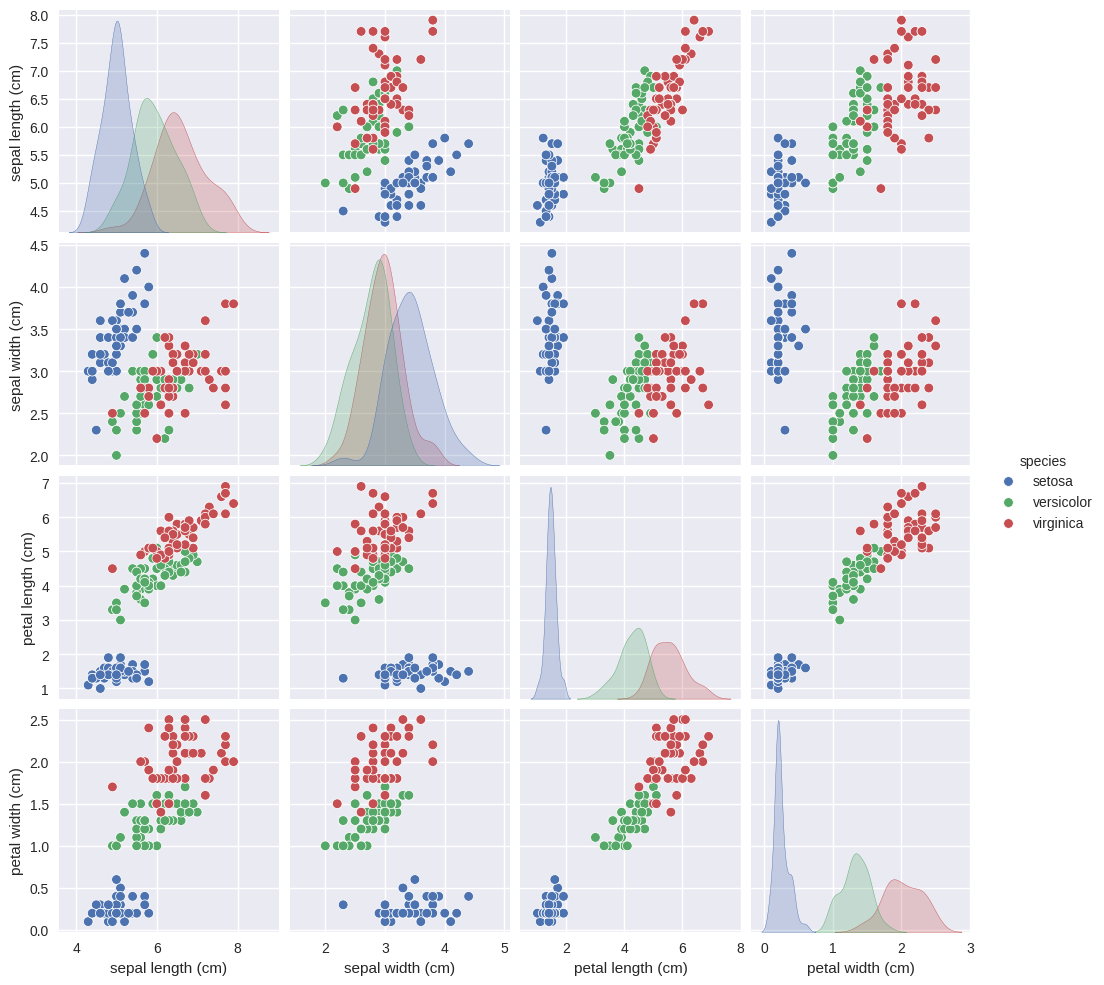

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Class names:", iris.target_names)

# Quick visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target_names[y.flatten()]
sns.pairplot(df, hue='species')
plt.show()

In [3]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


In [5]:
class NeuralNetwork:
    def __init__(self, input_size=4, hidden_size=5, output_size=3, learning_rate=0.1):
        # Xavier initialization (good practice)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        return loss

In [6]:
    def backward(self, y_true):
        m = y_true.shape[0]

        # Output layer error (delta)
        dZ2 = self.A2 - y_true

        # Gradients for W2 and b2
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer error
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)

        # Gradients for W1 and b1
        dW1 = np.dot(self.X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights (Gradient Descent)
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

In [7]:
    def train(self, X, y, epochs=1000, print_every=100):
        losses = []
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Compute loss
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)

            # Backward pass (Backpropagation)
            self.backward(y)

            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        return losses

Epoch 0, Loss: 4.1656
Epoch 200, Loss: 0.3112
Epoch 400, Loss: 0.0952
Epoch 600, Loss: 0.0755
Epoch 800, Loss: 0.0715
Epoch 1000, Loss: 0.0658
Epoch 1200, Loss: 0.0703
Epoch 1400, Loss: 0.0628
Epoch 1600, Loss: 0.0608
Epoch 1800, Loss: 0.0595


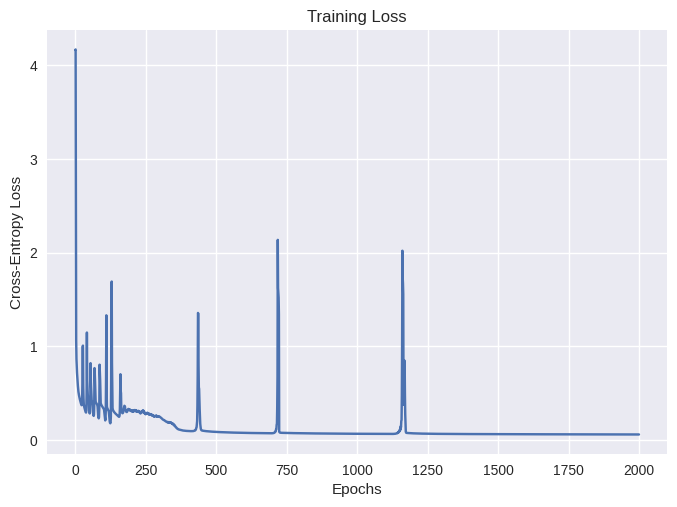

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

class NeuralNetwork:
    def __init__(self, input_size=4, hidden_size=5, output_size=3, learning_rate=0.1):
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        return loss

    def backward(self, y_true):
        m = y_true.shape[0]
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(self.X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=2000, print_every=200):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)
            self.backward(y)
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return losses

# --- Data load karo (Iris dataset example) ---
iris = load_iris()
X = iris.data  # 150 samples, 4 features
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Create and train network
nn = NeuralNetwork(learning_rate=0.2)
losses = nn.train(X_train, y_train, epochs=2000, print_every=200)

# Plot loss curve
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.show()

Clean Implementation with **scaling**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)   # For reproducibility

iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


In [13]:
class NeuralNetwork:
    def __init__(self, input_size=4, hidden_size=8, output_size=3, learning_rate=0.15):
        # He/Xavier Initialization
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        return loss

    def backward(self, y_true):
        m = y_true.shape[0]

        # Output layer
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(self.X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=1500, print_every=100):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)
            self.backward(y)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        return losses

Starting Training...

Epoch    0 | Loss: 1.5358
Epoch  200 | Loss: 0.1025
Epoch  400 | Loss: 0.0620
Epoch  600 | Loss: 0.0510
Epoch  800 | Loss: 0.0457
Epoch 1000 | Loss: 0.0427
Epoch 1200 | Loss: 0.0408
Epoch 1400 | Loss: 0.0395


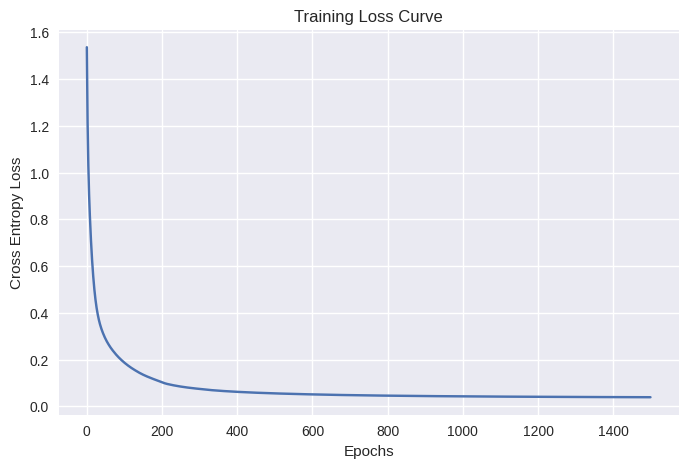

In [14]:
nn = NeuralNetwork(hidden_size=8, learning_rate=0.15)

print("Starting Training...\n")
losses = nn.train(X_train, y_train, epochs=1500, print_every=200)


plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.grid(True)
plt.show()

In [16]:
def predict(model, X):
    y_pred = model.forward(X)
    return np.argmax(y_pred, axis=1)

# Convert one-hot back to labels
y_train_true = np.argmax(y_train, axis=1)
y_test_true = np.argmax(y_test, axis=1)

train_pred = predict(nn, X_train)
test_pred = predict(nn, X_test)


print(f"Training Accuracy : {np.mean(train_pred == y_train_true)*100:.2f}%")
print(f"Test Accuracy     : {np.mean(test_pred == y_test_true)*100:.2f}%")


Training Accuracy : 98.33%
Test Accuracy     : 96.67%
